In [ ]:
import math
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
from kan import KAN as PyKAN
from sklearn.decomposition import PCA
from torch import nn

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 22})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

# Using PCA dimensionality reduction to qualitatively estimate the classifier's performance on the unlabeled challenge's test set

## Loading the data set

In [ ]:
train_x = pd.read_csv('../dataset/0-original/X.csv').drop('id', axis=1)
train_y = pd.read_csv('../dataset/0-original/y.csv').drop('id', axis=1)
train_y['trq_target'] = train_x['trq_measured'] / (train_y['trq_margin'] / 100 + 1)

train_mean, train_std = train_x.mean(), train_x.std()
train_x = (train_x - train_mean) / train_std
base_features = train_x.columns

valid_x = pd.read_csv('../dataset/0-original/X_validation.csv').drop('id', axis=1)
valid_x = (valid_x - train_mean) / train_std
test_x = pd.read_csv('../dataset/0-original/X_test.csv').drop('id', axis=1)
test_x = (test_x - train_mean) / train_std
valid_test_x = pd.concat([valid_x, test_x], ignore_index=True)

In [ ]:
def plot_3d_pca(data, loadings, labels, features=base_features, scale=0.5, ax=None, c=None, alpha=0.04, azim=180 + 55,
                only_faulty=False, ):
    for i in range(3):
        data[f'PC{i + 1}'] = data[features].dot(loadings[i, :])

    if ax is None:
        fig = plt.figure(figsize=(20 * scale, 20 * scale))
        ax = fig.add_subplot(111, projection='3d')
        ax.view_init(elev=25, azim=azim)
        plt.legend(loc="upper right")
        plt.grid(True)

    if c is None:
        c = {0: 'g', 1: 'r'}
    s = 0.5 * 750_000 / len(data)
    for label in [0, 1] if not only_faulty else [1]:
        ax.scatter(
            data[labels == label]['PC1'],
            data[labels == label]['PC2'],
            data[labels == label]['PC3'],
            c=c[label],
            label={0: 'Healthy', 1: 'Faulty'}[label], alpha=alpha, s=s
        )
    return ax

In [ ]:
pca = PCA(n_components=len(base_features))
pca.fit_transform(train_x[base_features])
train_loadings = pca.components_[:3]
plot_3d_pca(train_x, train_loadings, train_y['faulty'].values)

# BarH Loadings
fig, ax = plt.subplots(1, 3, figsize=(14, 6))
for i in range(3):
    norm = plt.Normalize(0, max(train_loadings[i]))
    colors = plt.cm.viridis(norm(abs(train_loadings[i])))
    ax[i].barh(base_features, train_loadings[i], color=colors, alpha=0.85)
    ax[i].set_title(f'PC{i + 1}')
    ax[i].axvline(0, color='k', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame({'PC1': train_loadings[0], 'PC2': train_loadings[1], 'PC3': train_loadings[2]}).to_csv('loadings.csv',
                                                                                                    index=False)

## Visualizing the valid/test set distribution

In [ ]:
ax = plot_3d_pca(train_x, train_loadings, train_y['faulty'].values, scale=0.5)

for i in range(3):
    valid_test_x[f'PC{i + 1}'] = valid_test_x[base_features].dot(train_loadings[i, :])
ax.scatter(
    valid_test_x['PC1'],
    valid_test_x['PC2'],
    valid_test_x['PC3'],
    c='tab:blue', label='test', alpha=0.35, s=1
)
plt.legend(loc="upper right")
plt.show()

# Predicting the valid/test sets

## Calculating derived features

In [ ]:
regression_features = ['trq_measured', 'oat', 'mgt', 'np', 'ng', 'mgt np ng', 'np ng^2', 'trq_measured_norm_da']
classification_features = ['trq_measured', 'oat', 'mgt', 'np', 'ng', 'oat ng^2', 'pa ng^2', 'oat^2 ng', 'mgt_norm_da',
                           'np_air_density']

In [ ]:
for df in [train_x, valid_test_x]:
    df['mgt np ng'] = df['mgt'] * df['np'] * df['ng']
    df['np ng^2'] = df['np'] * df['ng'] ** 2
    df['oat ng^2'] = df['oat'] * df['ng'] ** 2
    df['pa ng^2'] = df['pa'] * df['ng'] ** 2
    df['oat^2 ng'] = df['oat'] ** 2 * df['ng']

    df['da'] = (1.2376 * df['pa']) + (118.8 * (df['oat'] + 273.15)) - 1782
    df['trq_measured_norm_da'] = df['trq_measured'] / df['da']
    df['mgt_norm_da'] = df['mgt'] / df['da']

    T0 = 288.15  # Sea-level standard temperature (K)
    p0 = 101325  # Sea-level standard atmospheric pressure (Pa)
    a = 0.0065  # Temperature lapse rate (K/m)
    g = 9.80665  # Gravitational acceleration (m/s^2)
    R = 8.3144598  # Universal gas constant (J/(mol·K))
    RS = 287.05  # Specific gas constant for air (J/(kg·K))
    df['h_m'] = df['pa'] * 0.3048
    df['P'] = p0 * (1 - (a * df['h_m']) / T0) ** (g / (R * a))
    df['rho'] = df['P'] / (RS * (df['oat'] + 273.15))
    df['np_air_density'] = df['np'] / df['rho']

In [ ]:
class Py_KAN(nn.Module):
    def __init__(self, layers, is_regression, grid_size=3):
        super(Py_KAN, self).__init__()
        self.layers = layers
        self.grid_size = grid_size
        self.is_regression = is_regression
        self.model = PyKAN(width=self.layers, grid=self.grid_size, k=3, device=device)

    def forward(self, x):
        x = self.model(x)
        if self.is_regression:
            mu = x[:, 0]
            var = x[:, 1]
            return mu, var
        else:
            return x

## Torque Margin estimation

In [ ]:
regression_valid_test_x = valid_test_x[regression_features]
regression_train_x = train_x[regression_features]

In [ ]:
pyKANReg = Py_KAN(layers=[[len(regression_features), 0], [1, 0], [2, 0]], is_regression=True, grid_size=2)
pyKANReg.model = PyKAN.loadckpt('../2-torque_margin_pdf_regression/models/torque_target_stochastic_small_12-23-01_8.pt')
pyKANReg.eval()

In [ ]:
in_vars = ['$trq_{msr}$', 'oat', 'mgt', 'np', 'ng', '$mgt\\times np\\times ng$', '$np\\times ng^2$',
           '$\\dfrac{trq_{msr}}{da}$']
pyKANReg.model.plot(scale=0.75, in_vars=in_vars, out_vars=['μ', 'σ'],
                    varscale=0.45, figsize_base=(14, 10))

In [156]:
trq_target_pred = []
mu_mean = train_y['trq_target'].mean()
mu_std = train_y['trq_target'].std()

for i in range(math.ceil(len(regression_valid_test_x) / 8192)):
    x = regression_valid_test_x[i * 8192:min(len(regression_valid_test_x), (i + 1) * 8192)]
    x = torch.tensor(x.values, dtype=torch.float32, device=device)
    mu, _ = pyKANReg(x)
    mu = mu.detach().cpu().numpy() * mu_std + mu_mean  # <-- De-normalization
    trq_target_pred.extend(mu.tolist())
trq_target_pred = pd.Series(trq_target_pred)

In [157]:
predicted_trq_margin_train = pd.read_csv('../2-torque_margin_pdf_regression/prediction.csv')['trq_margin']
trq_margin_train_mean = predicted_trq_margin_train.mean()
trq_margin_train_std = predicted_trq_margin_train.std()

In [166]:
de_normalized_trq_measured = regression_valid_test_x['trq_measured'] * train_std['trq_measured'] + train_mean[
    'trq_measured']
trq_margin_pred = np.where(
    trq_target_pred != 0,
    (de_normalized_trq_measured / trq_target_pred - 1) * 100,
    0
)
trq_margin_pred = pd.Series(trq_margin_pred).replace('unset', 0).astype(float)
trq_margin_pred_normalized = (trq_margin_pred - trq_margin_train_mean) / trq_margin_train_std

## Fault Detection

In [167]:
classification_x = valid_test_x[classification_features]
classification_x.loc[:, ['trq_margin']] = trq_margin_pred_normalized
classification_train_x = train_x[classification_features]
classification_train_x.loc[:, ['trq_margin']] = train_y['trq_margin']

In [ ]:
pyKANClass = Py_KAN(layers=[[len(classification_features), 0], [0, 1], [1, 0]], is_regression=False, grid_size=2)
pyKANClass.model = PyKAN.loadckpt('../3-Fault_Detection/models/fault_detection_multi_15-48-05_0.pt')
pyKANClass.eval()

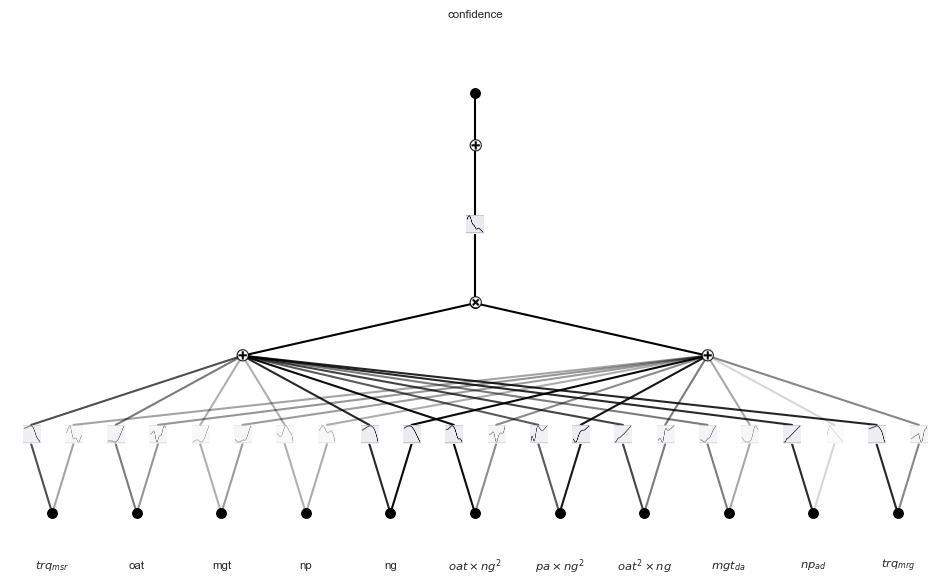

In [162]:
in_vars = ['$trq_{msr}$', 'oat', 'mgt', 'np', 'ng', '$oat\\times ng^2$', '$pa\\times ng^2$', '$oat^2\\times ng$',
           '$mgt_{da}$', '$np_{ad}$', '$trq_{mrg}$']
pyKANClass.model.plot(scale=0.75, in_vars=in_vars, out_vars=['confidence'], varscale=0.275, figsize_base=(16, 10))

In [169]:
labels = torch.tensor([])

for i in range(math.ceil(len(classification_x) / 8192)):
    x = classification_x[i * 8192:min(len(classification_x), (i + 1) * 8192)]
    x = torch.tensor(x.values, dtype=torch.float32, device=device)
    confidence = pyKANClass(x)
    labels = torch.cat((labels, torch.sigmoid(confidence).detach().cpu()))
labels = pd.Series(labels.squeeze())

# Plotting 3D PCA on valid/test set

C:\Users\MrPio\AppData\Local\Temp\ipykernel_26284\2282782962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'PC{i + 1}'] = data[features].dot(loadings[i, :])
C:\Users\MrPio\AppData\Local\Temp\ipykernel_26284\2282782962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'PC{i + 1}'] = data[features].dot(loadings[i, :])
C:\Users\MrPio\AppData\Local\Temp\ipykernel_26284\2282782962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

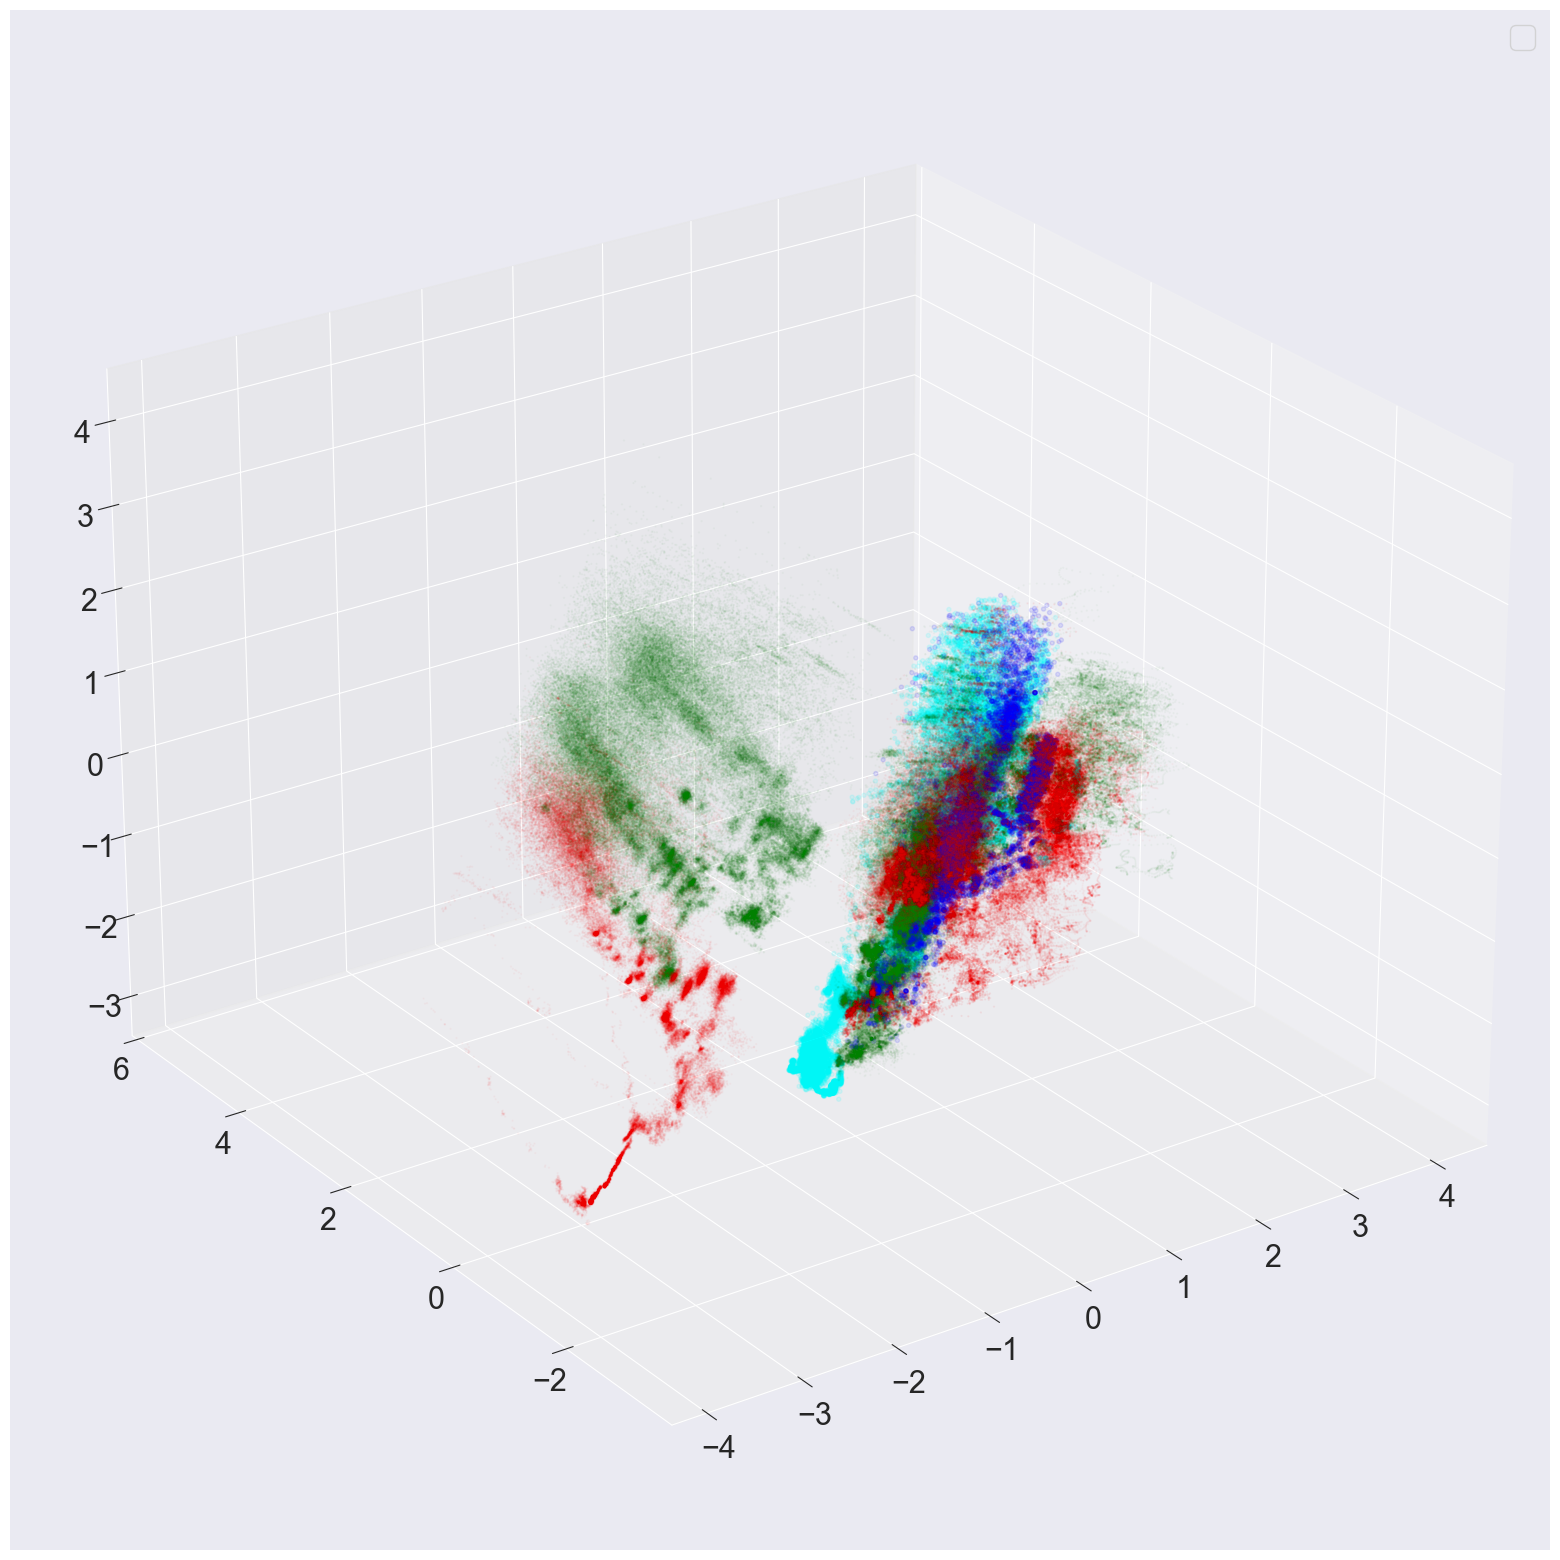

In [171]:
ax = plot_3d_pca(train_x[:], train_loadings, train_y['faulty'].values[:], scale=1, alpha=0.025)
plot_3d_pca(valid_test_x, train_loadings, labels > 0.5, c={0: 'cyan', 1: 'blue'}, ax=ax, alpha=0.1)
plt.show()

In [172]:
pd.DataFrame({'faulty': labels, 'trq_margin': trq_margin_pred, 'trq_target': trq_target_pred}).to_csv(
    'valid_test_y.csv', index=False)

# Using Shapley Value to find the relevance of each feature

In [173]:
def explain_with_shap(tag: str, dataset, samples=1000):
    def model_predict(x):
        with torch.no_grad():
            x = torch.tensor(x, dtype=torch.float32, device=device)
            return pyKANClass(x).cpu().numpy()

    random_indices = np.random.choice(len(dataset), size=samples, replace=False)
    random_samples = dataset.iloc[random_indices]
    explainer = shap.Explainer(model_predict, random_samples.values)
    shap_values = explainer(random_samples.values)
    with open(f'shap_values_{tag}.pkl', 'wb') as f:
        pickle.dump(shap_values, f)
    shap.summary_plot(shap_values.values, random_samples, plot_size=[18, 10], show=False)
    plt.savefig(f'{tag}.png', bbox_inches='tight', dpi=300)

PermutationExplainer explainer: 801it [04:23,  2.92it/s]                         
PermutationExplainer explainer: 801it [04:49,  2.66it/s]                         


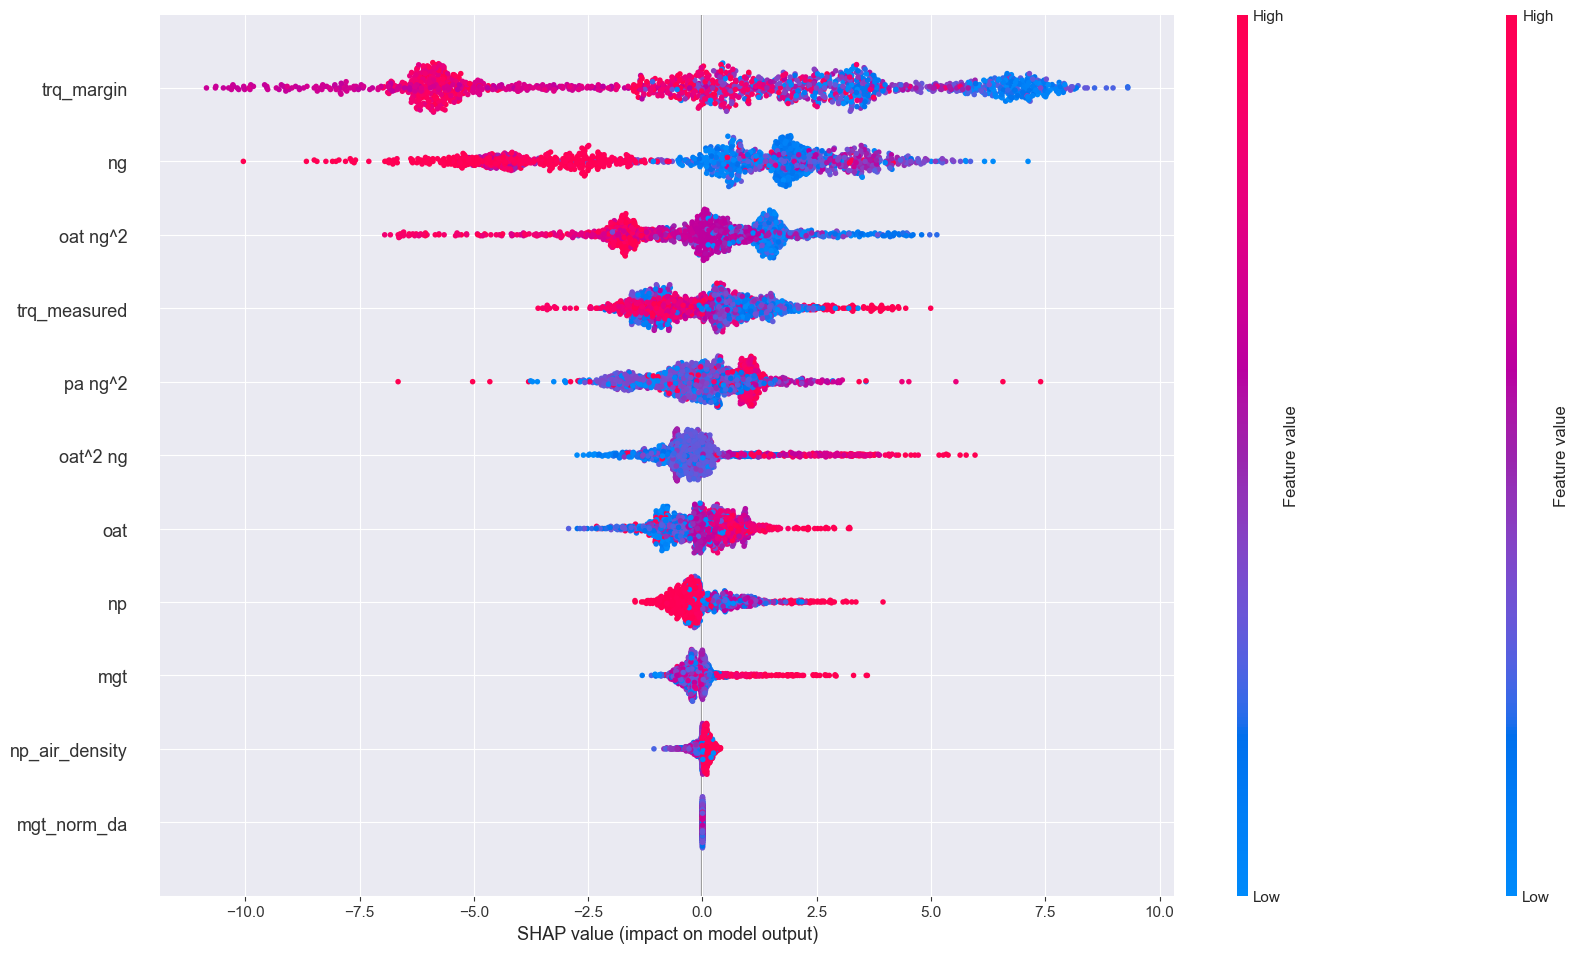

In [174]:
explain_with_shap('valid_test', classification_x, samples=800)
explain_with_shap('train', classification_train_x, samples=800)